In [2]:
from Lim_solver import smart_optimise
from neumann_rates import raw_overpass, raw_overpass_instant
import numpy as np
import matplotlib.pyplot as plt 
from tqdm import tqdm

In [3]:
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# Finite key per overpass as function of maximum elevation

24it [00:39,  1.65s/it]
24it [00:38,  1.59s/it]


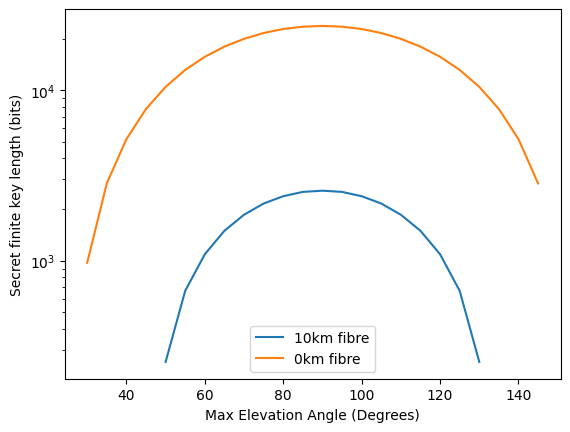

In [28]:
# with 10km fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
plt.plot(angle_range, skl, label="10km fibre")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
plt.plot(angle_range, skl, label="0km fibre")
plt.xlabel("Max Elevation Angle (Degrees)")
plt.ylabel("Secret finite key length (bits)")
plt.yscale("log")
plt.legend()

# Raw keysizes

17it [00:03,  5.09it/s]
17it [00:03,  5.12it/s]


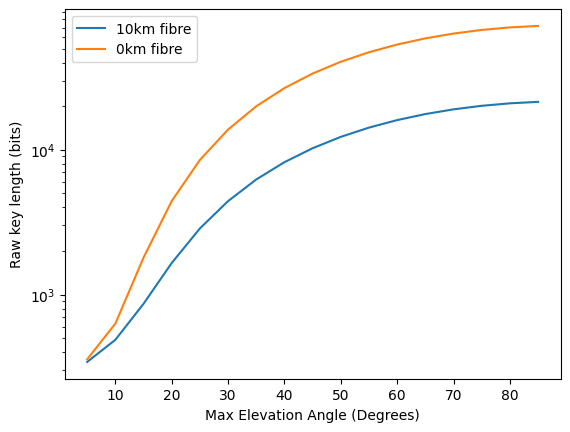

In [ ]:
# with 10km fibre
ms = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    ms+=[m]
plt.plot(angle_range, ms, label="10km fibre")

# without fibre
ms = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    ms+=[m]
plt.plot(angle_range, ms, label="0km fibre")
plt.xlabel("Max Elevation Angle (Degrees)")
plt.ylabel("Raw key length (bits)")
plt.yscale("log")
plt.legend()

# overpass losses as function of the max elevation angle

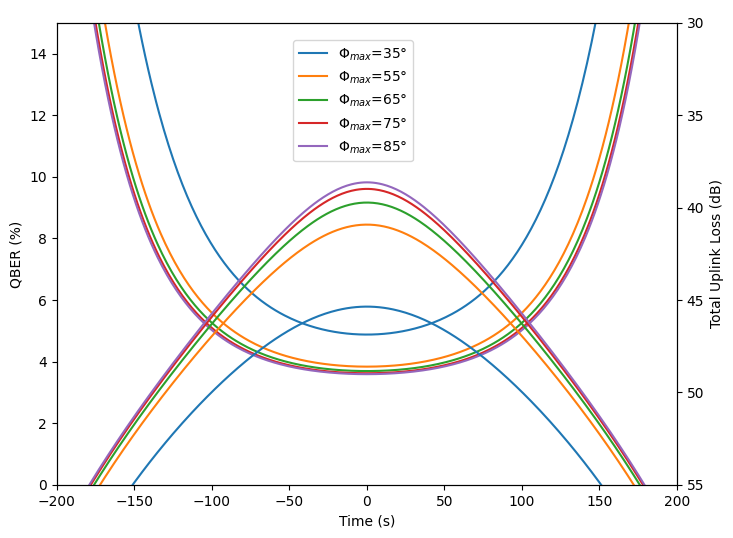

In [24]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
f, a1  = plt.subplots(1, 1, figsize=(8, 6))
a2 = a1.twinx()
a2.invert_yaxis()
for i,prof in enumerate(loss_profiles):
    if not angle_range[i] in [85,75,65,55,35]:continue
    qber, qx, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])
    a2.plot(prof[:,0], prof[:,1]+prof[:,2], label=rf"$\Phi_{{max}}$={angle_range[i]}°")
    a1.plot(prof[:,0], qber*100)
a1.set_xlim(-200, 200)
a1.set_xlabel("Time (s)")
a1.set_ylabel("QBER (%)")
a1.set_ylim(0, 15)

a2.set_xlim(-200, 200)
a2.set_xlabel("Time (s)")
a2.set_ylabel("Total Uplink Loss (dB)")
a2.set_ylim(55, 30)
f.legend(loc=[0.4,0.7])

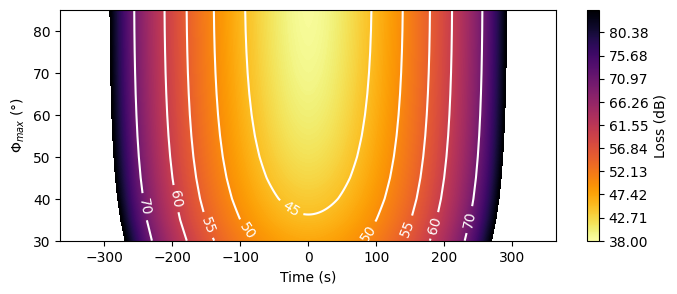

In [78]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
angle_range=np.arange(30, 90, 5)
loss_profiles = [np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.figure(figsize=(8,3))

X, Y = np.meshgrid(loss_profiles[np.argmax([p.shape[0] for p in loss_profiles])][:,0], angle_range)
Zloss = []
max_length = np.max([p.shape[0] for p in loss_profiles])
for prof in loss_profiles:

    buffer_length = (max_length - prof[:,0].shape[0])//2
    if prof[:,0].shape[0]%2 == max_length%2:
        Zloss.append(np.pad(prof[:,1]+prof[:,2], (buffer_length, buffer_length),"constant",constant_values=np.nan))
    else:
        Zloss.append(np.pad(prof[:,1]+prof[:,2], (buffer_length+1, buffer_length), "constant", constant_values=np.nan))
# plt.ylim(30, 90)
CS=plt.contour(X, Y, Zloss,levels=[45,50,55,60,70],colors="white")
plt.contourf(X, Y, Zloss,levels=np.linspace(38,85,500), cmap="inferno_r")

plt.colorbar(label="Loss (dB)")

plt.xlabel("Time (s)")
plt.clabel(CS, fontsize=10,colors='white')
plt.ylabel(rf"$\Phi_{{max}}~(\degree)$")
plt.show()

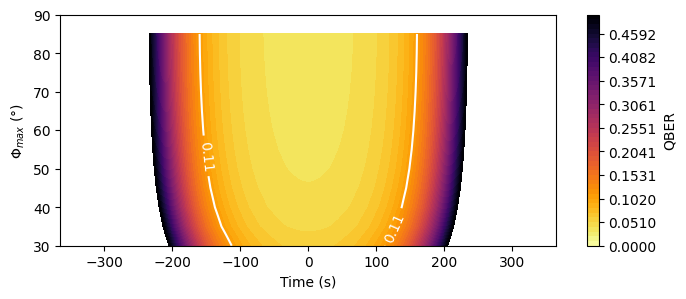

In [80]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]

plt.figure(figsize=(8,3))

X, Y = np.meshgrid(loss_profiles[np.argmax([p.shape[0] for p in loss_profiles])][:,0], angle_range)
Zqber = []
max_length = np.max([p.shape[0] for p in loss_profiles])
for prof in loss_profiles:

    buffer_length = (max_length - prof[:,0].shape[0])//2
    if prof[:,0].shape[0]%2 == max_length%2:
        Zqber.append(np.pad(raw_overpass_instant(params, prof[:,1]+prof[:,2])[0], (buffer_length, buffer_length), "constant", constant_values=np.nan))
    else:
        Zqber.append(np.pad(raw_overpass_instant(params, prof[:,1]+prof[:,2])[0], (buffer_length+1, buffer_length), "constant", constant_values=np.nan))
CS=plt.contour(X, Y, Zqber,levels=[0.11], colors="white")
plt.contourf(X, Y, Zqber,levels=np.linspace(0,0.5,50), cmap="inferno_r")

plt.colorbar(label="QBER")
 
plt.ylim(30, 90)
plt.xlabel("Time (s)")
plt.clabel(CS, fontsize=10,colors='white')
plt.ylabel(rf"$\Phi_{{max}}~(\degree)$")
plt.show()

# optimize central integration window

17it [05:37, 19.83s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

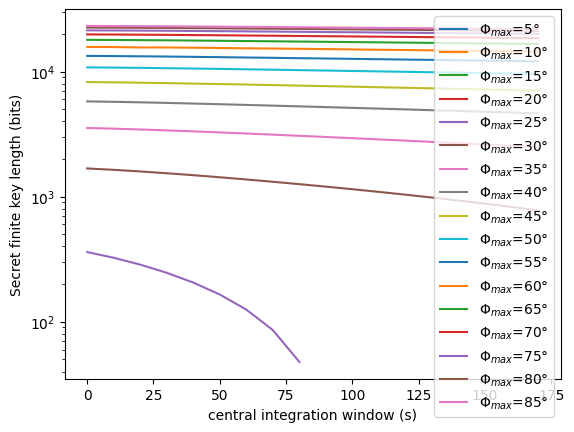

In [30]:
# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])



    result = []
    for k in range(0,180,10):
        central_block = slice(k,len(prof[:,0])-k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,180,10),result[::-1], label=rf"$\Phi_{{max}}$={angle_range[i]}°")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

17it [1:48:02, 381.32s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

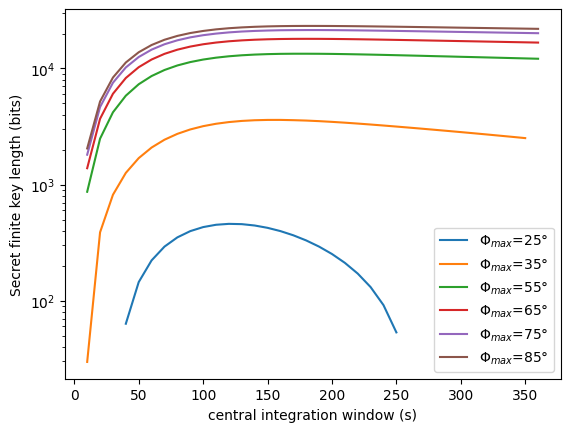

In [36]:
# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    if not angle_range[i] in [85,75,65,55,35, 25]:continue
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])


    max_t =int(len(prof[:,0])/2)
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, label=rf"$\Phi_{{max}}$={angle_range[i]}°")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

# two windows

100%|██████████| 37/37 [14:10<00:00, 22.99s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

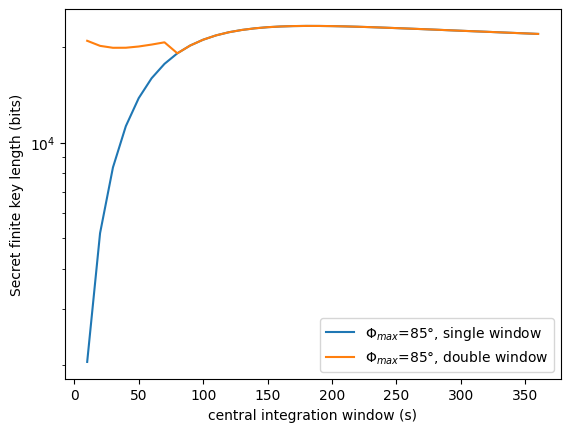

In [20]:
# without fibre
params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
for i,prof in enumerate(loss_profiles):
    if not angle_range[i] in [85]:continue
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])
    max_t =int(len(prof[:,0])/2)
    result_single = []
    result_double = []
    for k in tqdm(range(0,max_t,10)):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result_single += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
        #find the optimal integration window for the second window, assuming it is symmetric
        result_two = []
        for j in range(0,int(len(prof[:,0])/2)-k,10):
            second_block = slice(j, int(len(prof[:,0])/2)-k)
            CC_m_overpass_outer = m[second_block]
            avg_qber_outer = np.sum(np.array(E_b[second_block])*np.array(CC_m_overpass_outer))/np.sum(CC_m_overpass_outer)
            result_two += [2*smart_optimise(2*np.sum(CC_m_overpass_outer), avg_qber_outer, 1e-6, np.log2(10**8), 1.19) * np.sum(CC_m_overpass_outer)]
        result_double += [np.max(result_two)]
    plt.plot( range(0,max_t,10),result_single, label=rf"$\Phi_{{max}}$={angle_range[i]}°, single window")
    plt.plot( range(0,max_t,10),np.nan_to_num(np.array(result_double))+np.array(result_single), label=rf"$\Phi_{{max}}$={angle_range[i]}°, double window")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


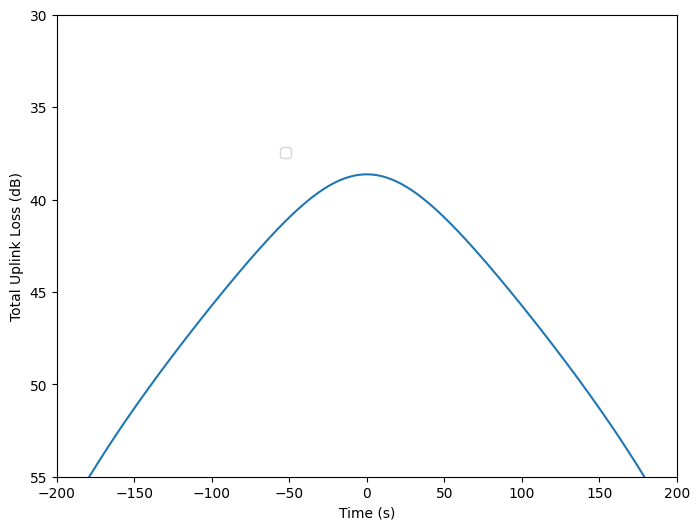

In [27]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
f, a2  = plt.subplots(1, 1, figsize=(8, 6))
for i,prof in enumerate(loss_profiles):
    if not angle_range[i] in [85]:continue
    qber, qx, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])
    a2.plot(prof[:,0], prof[:,1]+prof[:,2])

a2.set_xlim(-200, 200)
a2.set_xlabel("Time (s)")
a2.set_ylabel("Total Uplink Loss (dB)")
a2.set_ylim(55, 30)
f.legend(loc=[0.4,0.7])

25it [00:49,  1.97s/it]
25it [00:45,  1.81s/it]


Text(0, 0.5, 'P($\\theta$)')

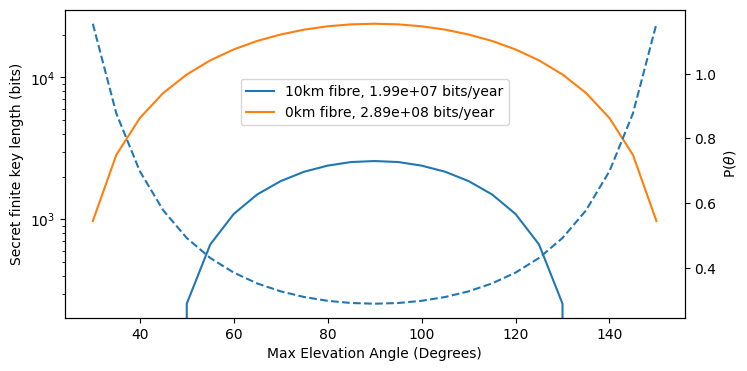

In [57]:
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3),"--")
ax2.set_ylabel(r"P($\theta$)")


25it [03:57,  9.48s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

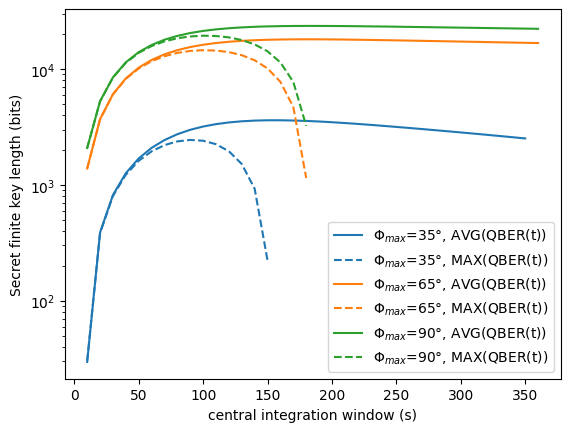

In [7]:
# without fibre
skl = []
colors= ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
l=0
for i,prof in tqdm(enumerate(loss_profiles)):
    if not angle_range[i] in [90,65,35]:continue
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])


    max_t =int(len(prof[:,0])/2)
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, label=rf"$\Phi_{{max}}$={angle_range[i]}°, AVG(QBER(t))",color=colors[l])

    # conservative estimate
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        if len(E_b[central_block])==0:worst_qber=0
        else:worst_qber = np.nanmax(E_b[central_block])
        result += [smart_optimise(np.sum(CC_m_overpass_inner),worst_qber, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, "--",label=rf"$\Phi_{{max}}$={angle_range[i]}°, MAX(QBER(t))",color=colors[l])
    l+=1
plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')